In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv('https://raw.githubusercontent.com/KeithGalli/Regression-Example/refs/heads/master/insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.924
1,18.0,male,33.770,1.0,no,Southeast,1725.5523
2,28.0,male,33.000,3.0,no,southeast,$4449.462
3,33.0,male,22.705,0.0,no,northwest,$21984.47061
4,32.0,male,28.880,0.0,no,northwest,$3866.8552


In [7]:
df.isna().sum()
df.dropna(inplace= True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1208 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1208 non-null   float64
 1   sex       1208 non-null   object 
 2   bmi       1208 non-null   float64
 3   children  1208 non-null   float64
 4   smoker    1208 non-null   object 
 5   region    1208 non-null   object 
 6   charges   1208 non-null   object 
dtypes: float64(3), object(4)
memory usage: 75.5+ KB


In [8]:
df['region'] = df['region'].str.lower()
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [9]:
df['sex'].unique()

array(['female', 'male', 'woman', 'F', 'man', 'M'], dtype=object)

In [10]:
MALE = 'male'
FEMALE = 'female'
sex_mapping = {'F': FEMALE, 'woman': FEMALE, 'M': MALE, 'man': MALE}
df['sex'] = df['sex'].replace(sex_mapping)
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [11]:
# smoker column to boolean
df['smoker'] = (df['smoker'] == 'yes')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1208 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1208 non-null   float64
 1   sex       1208 non-null   object 
 2   bmi       1208 non-null   float64
 3   children  1208 non-null   float64
 4   smoker    1208 non-null   bool   
 5   region    1208 non-null   object 
 6   charges   1208 non-null   object 
dtypes: bool(1), float64(3), object(3)
memory usage: 67.2+ KB


In [12]:
df['charges'] = df['charges'].astype(str).str.strip('$').astype('Float64')

df.sample(10)

,age,sex,bmi,children,smoker,region,charges
773,19.0,female,28.880,0.0,True,northwest,17748.5062
1070,37.0,male,37.070,1.0,True,southeast,39871.7043
414,19.0,female,35.150,0.0,False,northwest,2134.9015
761,23.0,male,35.200,1.0,False,southwest,2416.955
1238,37.0,male,22.705,3.0,False,northeast,6985.50695
1219,38.0,female,30.210,3.0,False,northwest,7537.1639
751,21.0,male,28.975,0.0,False,northwest,1906.35825
1142,-52.0,female,24.860,0.0,False,southeast,27117.99378
1013,48.0,male,32.300,1.0,False,northwest,8765.249
508,24.0,female,25.270,0.0,False,northeast,3044.2133


In [13]:
# Change -column to absolute values
insurance_pos = df.apply(lambda x: x.abs() if np.issubdtype(x.dtype.type, np.number) else x)
insurance_pos.sample(10)

,age,sex,bmi,children,smoker,region,charges
842,23.0,female,32.780,2.0,True,southeast,36021.0112
89,55.0,female,26.980,0.0,False,northwest,11082.5772
556,46.0,male,33.440,1.0,False,northeast,8334.5896
924,43.0,male,23.200,0.0,False,southwest,6250.435
566,38.0,female,40.565,1.0,False,northwest,6373.55735
54,40.0,female,28.690,3.0,False,northwest,8059.6791
716,49.0,female,22.610,1.0,False,northwest,9566.9909
27,55.0,female,32.775,2.0,False,northwest,12268.63225
676,55.0,female,40.810,3.0,False,southeast,12485.8009
1149,42.0,male,34.100,0.0,False,southwest,5979.731


In [14]:
insurance_pos.to_csv('insurance_cleaned.csv', index= False)

# Scatter Plot of Relationships between variables and charges

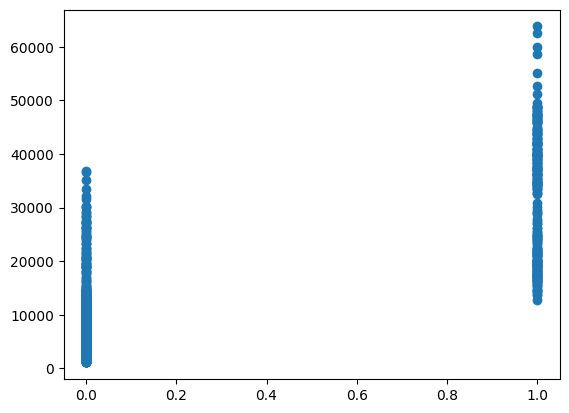

In [15]:
import matplotlib.pyplot as plt
df = insurance_pos.copy()

plt.scatter(df['smoker'], df['charges'])

In [22]:
df_new = pd.get_dummies(df, prefix=['region'], columns=['region'])
df_new = df_new.drop(columns=['region_northwest'])

df_new['smoker'] = df_new['smoker'].astype('Int64')
df_new['sex'] = (df_new['sex'] == 'male').astype('Int64')
df_new.drop(columns=['children'], inplace= True)

df_new.head()

,age,sex,bmi,smoker,charges,region_northeast,region_southeast,region_southwest
0,19.0,0,27.900,1,16884.924,False,False,True
1,18.0,1,33.770,0,1725.5523,False,True,False
2,28.0,1,33.000,0,4449.462,False,True,False
3,33.0,1,22.705,0,21984.47061,False,False,False
4,32.0,1,28.880,0,3866.8552,False,False,False
